# Bay Area patient sample points

Reproducible generation of the 5,000-patient location dataset used in `CA_simulations.jl`, `decision_tree_build.jl`, and the manuscript's San Francisco Bay Area analyses.

The canonical output for the paper is `../sampled_points/CA_points.csv`. This notebook reproduces the same methodology with a fixed random seed and writes its output to a separately-named file (`../sampled_points/CA_points_regenerated.csv`) so the canonical file is never accidentally overwritten.

## Methods overview

Patient locations are drawn from a population-density-weighted distribution across the nine-county Bay Area, then constrained to land. Four steps:

1. **Mask** the 30 m Meta/CIESIN US population raster to a Bay Area boundary polygon.
2. **Sample** locations from the masked raster with probability proportional to cell population, with replacement (`numpy.random.choice`).
3. **Inspect** duplicate coordinates (a natural consequence of replacement sampling on a discrete grid).
4. **Land-filter** sampled points against the Natural Earth 10 m land polygon and trim to exactly `NUM_SAMPLES`.

The result is a CSV with one row per simulated patient encounter, carrying `Longitude`, `Latitude`, a WKT `geometry`, and Natural Earth land attributes (`featurecla`, `scalerank`, `min_zoom`).

## Data sources

| Dataset | Vintage | Used for | Source |
|---|---|---|---|
| Meta/CIESIN US high-resolution population density (30 m) | 2019-07-01 | Sampling weights (Steps 1–2) | [HDX](https://data.humdata.org/dataset/united-states-high-resolution-population-density-maps-demographic-estimates) |
| Bay Area ZIP code polygons | 2017 release | Bay Area region mask (Step 1) | [UC Berkeley Geospatial Data](https://geodata.lib.berkeley.edu/catalog/ark28722-s7888q) |
| Natural Earth 10 m physical land | v5.1.1 | Land filter (Step 4) | [Natural Earth](https://www.naturalearthdata.com/downloads/10m-physical-vectors/) |

Place all input files under `./data/` before running. See `README.md` for download instructions and exact file layout.

## Reproducibility

| Parameter | Value |
|---|---|
| Random seed (`random.seed`, `numpy.random.seed`) | `42` |
| Target final sample size (`NUM_SAMPLES`) | `5000` |
| Initial oversample factor (`OVERSAMPLE_FACTOR`) | `1.10` |
| Python interpreter | 3.11+ recommended |
| Pinned dependencies | `requirements.txt` |

Re-running with the same seed reproduces this notebook's output exactly. The canonical `CA_points.csv` was generated with a different seed; the regenerated CSV is therefore statistically equivalent but not bit-identical.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
import matplotlib.pyplot as plt

# --- Reproducibility ----------------------------------------------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- Sampling parameters ------------------------------------------------------
NUM_SAMPLES = 10_000           # target row count of the final CSV
OVERSAMPLE_FACTOR = 1.10      # draw 10 % extra so the land filter can drop without dropping us below NUM_SAMPLES
DROP_DUPLICATES = False       # keep duplicate coordinates by default (see Step 3 for rationale)

# --- Paths --------------------------------------------------------------------
DATA_DIR = Path("data")
VRT_FILE = DATA_DIR / "population_usa_2019-07-01.vrt"                 # Meta/CIESIN raster index
REGION_SHP = DATA_DIR / "bayarea_zipcodes.shp"                        # Bay Area mask polygon
LAND_SHP = DATA_DIR / "ne_10m_land" / "ne_10m_land.shp"               # Natural Earth land polygon

OUT_DIR = Path("../sampled_points")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_CSV = OUT_DIR / "CA_points_regenerated.csv"


## Step 1 — Mask the population raster to the Bay Area

The Meta/CIESIN raster covers the entire United States. We clip it to the Bay Area's ZIP-code polygon union so that sampling weights are zero outside the study region. The masked raster is returned in WGS 84 (EPSG:4326), the raster's native CRS.

In [2]:
def load_population_masked(vrt_path: Path, region_shp_path: Path):
    """Open a population raster and mask it to a region polygon.

    Returns
    -------
    population : np.ndarray
        2D array of per-cell population density (NaN outside the region or on no-data cells).
    transform : affine.Affine
        Geo-transform mapping (row, col) -> (lon, lat) in the raster's CRS.
    """
    region = gpd.read_file(region_shp_path)
    with rasterio.open(vrt_path) as src:
        if str(region.crs) != src.crs.to_string():
            region = region.to_crs(src.crs)
        out_image, transform = mask(src, region.geometry, crop=True)
        nodata = src.meta["nodata"]
    population = np.where(out_image[0] == nodata, np.nan, out_image[0])
    return population, transform


population, transform = load_population_masked(VRT_FILE, REGION_SHP)
n_valid_cells = int(np.sum(~np.isnan(population)))
print(f"Raster shape: {population.shape}  ({n_valid_cells:,} valid cells inside Bay Area)")


Raster shape: (5804, 5043)  (1,254,152 valid cells inside Bay Area)


## Step 2 — Population-weighted sample with oversampling

We draw `NUM_SAMPLES * OVERSAMPLE_FACTOR` cell indices weighted by population, with replacement, then convert each to its geographic centroid. The oversample lets the downstream land filter drop a small fraction of points without bringing the final count below `NUM_SAMPLES`.

In [3]:
def sample_population_weighted(population: np.ndarray, transform, n: int, rng: np.random.Generator):
    """Draw n (lon, lat) samples from a population raster, weighted by cell population."""
    flat = population.flatten()
    valid = np.flatnonzero(flat > 0)               # NaN > 0 is False, so this also filters no-data
    weights = flat[valid] / flat[valid].sum()
    chosen = rng.choice(valid, size=n, p=weights)
    rows, cols = np.unravel_index(chosen, population.shape)
    return [rasterio.transform.xy(transform, r, c) for r, c in zip(rows, cols)]


rng = np.random.default_rng(RANDOM_SEED)
n_initial = int(NUM_SAMPLES * OVERSAMPLE_FACTOR)
sample_lonlat = sample_population_weighted(population, transform, n_initial, rng)
print(f"Drew {len(sample_lonlat):,} points (oversample = {NUM_SAMPLES:,} × {OVERSAMPLE_FACTOR})")


Drew 11,000 points (oversample = 10,000 × 1.1)


## Step 3 — Inspect duplicate coordinates

The population raster is a discrete grid of ~30 m cells, and `np.random.choice` defaults to sampling **with replacement**. When two draws hit the same cell, they map to the same geographic centroid — i.e. literally identical lon/lat values. By the birthday-paradox math, this collision rate is ~1 % at 5,000 draws.

These duplicates are a legitimate outcome of population-weighted sampling with replacement (two stroke events can occur at the same location). The canonical CSV was generated with duplicates kept, so we follow the same convention by default (`DROP_DUPLICATES = False`).

In [4]:
points = pd.DataFrame(sample_lonlat, columns=["longitude", "latitude"])

duplicated = points.duplicated(subset=["longitude", "latitude"], keep=False)
n_dup_rows = int(duplicated.sum())
n_dup_groups = int(points.loc[duplicated, ["longitude", "latitude"]].drop_duplicates().shape[0])
print(f"Duplicate-coordinate rows: {n_dup_rows:,} ({n_dup_rows / len(points):.2%})")
print(f"Distinct repeated locations: {n_dup_groups:,}")

if DROP_DUPLICATES:
    before = len(points)
    points = points.drop_duplicates(subset=["longitude", "latitude"]).reset_index(drop=True)
    print(f"Dropped {before - len(points):,} duplicate rows.")
else:
    print("Keeping duplicates (DROP_DUPLICATES = False).")


Duplicate-coordinate rows: 207 (1.88%)
Distinct repeated locations: 100
Keeping duplicates (DROP_DUPLICATES = False).


## Step 4 — Land filter against Natural Earth, trim to N

The Bay Area boundary mask in Step 1 already excludes the ocean and most of the bay, but cell centroids can still land in water on the polygon edges. A second spatial join against the Natural Earth land polygon drops these residual water points and attaches Natural Earth attributes (`featurecla`, `scalerank`, `min_zoom`) to each row, matching the schema of the canonical CSV.

After the filter, we trim to exactly `NUM_SAMPLES` rows. If the oversample was insufficient, the cell raises an informative error.

In [5]:
# Points are returned by the raster in WGS 84; declare it explicitly so the join CRS-aligns correctly.
points_gdf = gpd.GeoDataFrame(
    points.copy(),
    geometry=[Point(xy) for xy in zip(points.longitude, points.latitude)],
    crs="EPSG:4326",
)

land = gpd.read_file(LAND_SHP)
if points_gdf.crs != land.crs:
    points_gdf = points_gdf.to_crs(land.crs)

on_land = gpd.sjoin(points_gdf, land, how="inner", predicate="intersects").drop(columns="index_right")
on_land = on_land.rename(columns={"longitude": "Longitude", "latitude": "Latitude"})

if len(on_land) < NUM_SAMPLES:
    raise RuntimeError(
        f"Land filter left {len(on_land):,} points, fewer than NUM_SAMPLES = {NUM_SAMPLES:,}. "
        f"Increase OVERSAMPLE_FACTOR (currently {OVERSAMPLE_FACTOR}) and re-run."
    )

dropped = len(points_gdf) - len(on_land)
final = on_land.head(NUM_SAMPLES).reset_index(drop=True)
print(f"Land filter:   {len(points_gdf):,} → {len(on_land):,}  ({dropped} dropped to water)")
print(f"Trim to N:     {len(on_land):,} → {len(final):,}")
print(f"Output columns: {list(final.columns)}")

final.to_csv(OUTPUT_CSV, index=False)
print(f"\nWrote {OUTPUT_CSV}")


Land filter:   11,000 → 10,981  (19 dropped to water)
Trim to N:     10,981 → 10,000
Output columns: ['Longitude', 'Latitude', 'geometry', 'featurecla', 'scalerank', 'min_zoom']

Wrote ../sampled_points/CA_points_regenerated.csv


## Step 5 — Visualize

The Bay Area ZIP polygons provide visual context; sampled points are overlaid in red. Both layers are reprojected to WGS 84 for human-readable lon/lat axes.

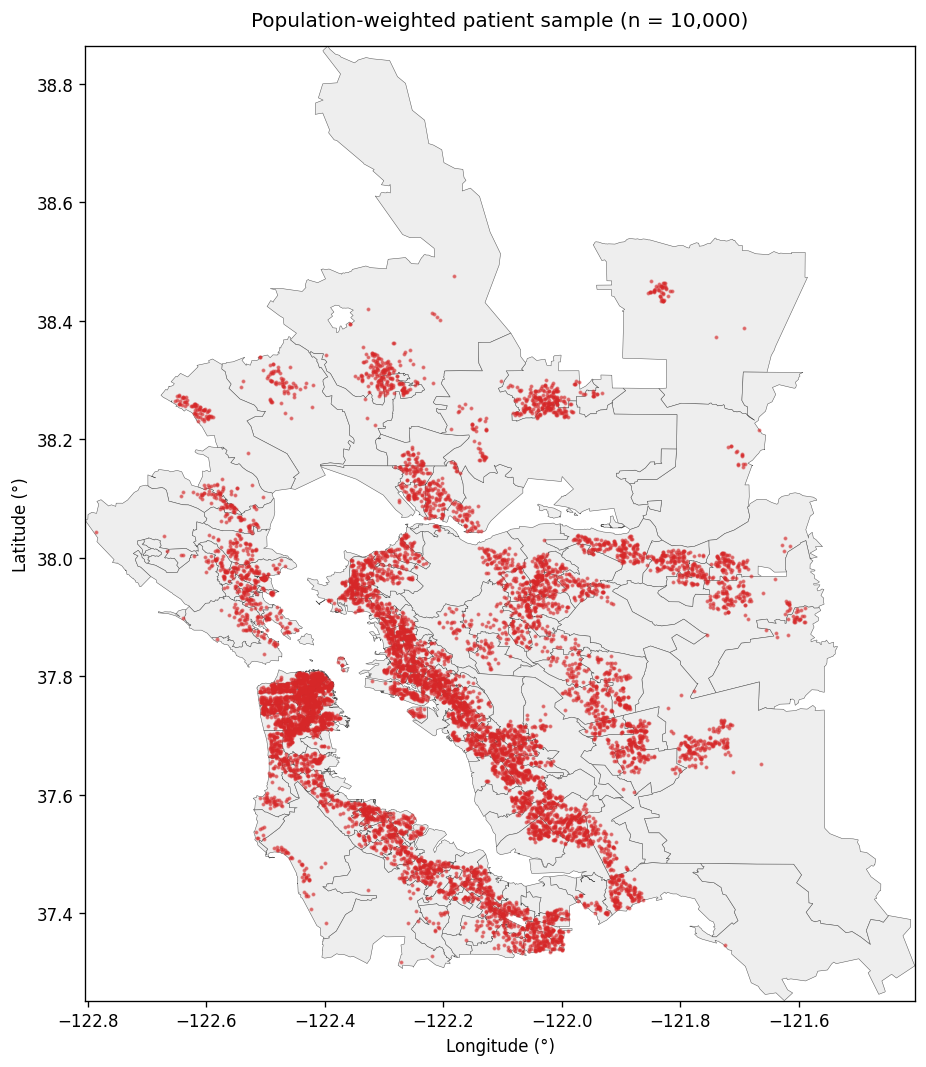

In [6]:
bay_area = gpd.read_file(REGION_SHP).to_crs("EPSG:4326")
points_4326 = final.to_crs("EPSG:4326")

fig, ax = plt.subplots(figsize=(8, 9), dpi=120)
bay_area.plot(ax=ax, color="#eeeeee", edgecolor="#555555", linewidth=0.3)
points_4326.plot(ax=ax, marker="o", color="#d62728", markersize=2, alpha=0.5)

xmin, ymin, xmax, ymax = bay_area.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"Population-weighted patient sample (n = {len(final):,})", pad=12)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


## Summary

The notebook produced `../sampled_points/CA_points_regenerated.csv` with the same column schema as the canonical `CA_points.csv` checked into the repo. Side-by-side comparison:

In [7]:
CANONICAL_CSV = Path("..") / "sampled_points" / "CA_points.csv"

summary = pd.DataFrame(
    {
        "Canonical": [
            CANONICAL_CSV.name,
            int(pd.read_csv(CANONICAL_CSV).shape[0]) if CANONICAL_CSV.exists() else None,
            ", ".join(pd.read_csv(CANONICAL_CSV, nrows=0).columns) if CANONICAL_CSV.exists() else None,
        ],
        "Regenerated (this run)": [
            OUTPUT_CSV.name,
            len(final),
            ", ".join(final.columns),
        ],
    },
    index=["File", "Row count", "Columns"],
)
summary


,Canonical,Regenerated (this run)
File,CA_points.csv,CA_points_regenerated.csv
Row count,5000,10000
Columns,"Longitude, Latitude, geometry, featurecla, sca...","Longitude, Latitude, geometry, featurecla, sca..."
